In [12]:
import numpy as np
import matplotlib.pyplot as plt

## arc_point

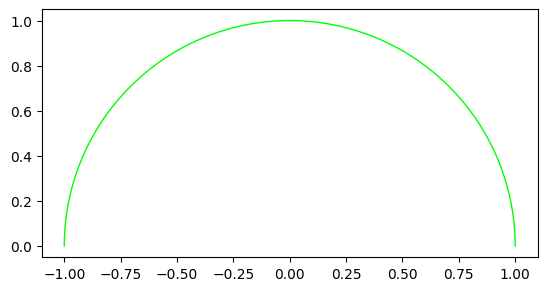

In [13]:
def arc_point(
    center=(0, 0),
    point1=(1, 0),
    point2=(-1, 0),
    color="#0f0",
    alpha=1,
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="r",
    markeredgecolor="k",
    markeredgewidth=1,
    ax=None,
    plot=True,
    direction="ccw",  # 'ccw' or 'cw'
    return_arc=False,
    **kwargs,
):
    """
    画通过 point1 到 point2 的圆弧（以 center 为圆心），
    如果 point1 和 point2 的半径不同，会使用 point1 的半径并打印警告。
    返回 (x, y) 数组; 如果 plot=True，会在给定的 ax 上绘图。
    """
    # 计算端点到圆心的向量
    v1 = np.array(point1) - np.array(center)
    v2 = np.array(point2) - np.array(center)

    # 计算向量的模长（半径）
    r1 = np.linalg.norm(v1)
    r2 = np.linalg.norm(v2)
    if r1 == 0 or r2 == 0:
        raise ValueError("point1/point2 不应与 center 重合")
    if abs(r1 - r2) > 1e-6:
        print(f"Warning: radii differ (r1={r1:.6g}, r2={r2:.6g}); using r1 for arc")
    r = r1

    # 计算两点对应的角（弧度）
    theta1 = np.arctan2(v1[1], v1[0]) % (2 * np.pi)
    theta2 = np.arctan2(v2[1], v2[0]) % (2 * np.pi)

    # 根据方向生成角度序列（确保按期望方向从 point1 到 point2）
    if direction == 'ccw':
        if theta2 <= theta1:
            theta2 = theta2 + 2 * np.pi
        theta = np.linspace(theta1, theta2, points)
    else:  # cw
        if theta1 <= theta2:
            theta1 = theta1 + 2 * np.pi
        theta = np.linspace(theta1, theta2, points)[::-1]

    # 计算弧上点坐标
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)

    if not plot:
        return x, y

    # 绘图：校验 ax 并绘制
    if ax is None:
        ax = plt.gca()
    elif isinstance(ax, bool):
        raise ValueError("ax 参数不能是布尔值；如果不想绘图请使用 plot=False")

    arc = ax.plot(
        x,
        y,
        color=color,
        alpha=alpha,
        linestyle=linestyle,
        linewidth=linewidth,
        label=label,
        marker=marker,
        markersize=markersize,
        markerfacecolor=markerfacecolor,
        markeredgecolor=markeredgecolor,
        markeredgewidth=markeredgewidth,
        **kwargs,
    )
    ax.set_aspect("equal", adjustable="box")
    if label:
        ax.legend()
    if return_arc:
        return arc[0] if arc else None
arc_point(plot=True)

## arc_point_inverse

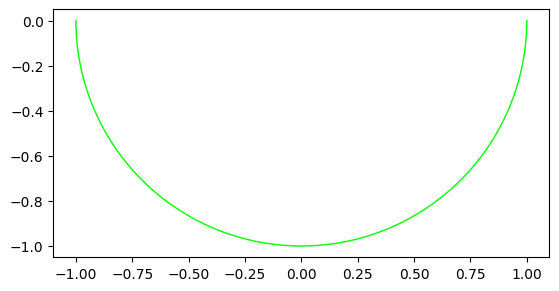

In [14]:
def arc_point_inverse(
    center=(0, 0),
    point1=(1, 0),
    point2=(-1, 0),
    color="#0f0",
    alpha=1,
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="r",
    markeredgecolor="k",
    markeredgewidth=1,
    ax=None,
    plot=True,
    direction="cw",  # 'ccw' or 'cw'
    return_arc=False,
    **kwargs,
):
    arc_point(
        center=center,
        point1=point1,
        point2=point2,
        color=color,
        alpha=alpha,
        points=points,
        linestyle=linestyle,
        linewidth=linewidth,
        label=label,
        marker=marker,
        markersize=markersize,
        markerfacecolor=markerfacecolor,
        markeredgecolor=markeredgecolor,
        markeredgewidth=markeredgewidth,
        ax=ax,
        plot=plot,
        direction=direction,
        return_arc=return_arc,
        **kwargs,
    )
arc_point_inverse()

## arc_degree

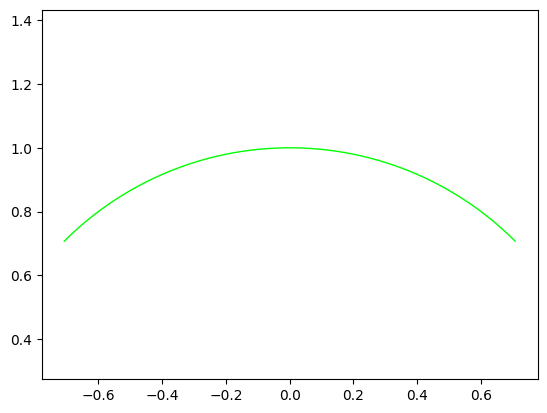

In [15]:
def arc(
    r=1,
    angle1=45,
    angle2=135,
    rotation=0,
    color="#0f0",
    alpha=1,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="b",
    markeredgecolor="r",
    markeredgewidth=1,
    ax=None,
    use_degree=True,
    plot=True,
    direction="ccw",  # 'ccw' or 'cw'
    return_arc=False,
    **kwargs,
):
    # 1) 生成角度数组并统一为弧度
    if use_degree:
        theta1 = np.deg2rad(angle1)
        theta2 = np.deg2rad(angle2)
        rot = np.deg2rad(rotation)
    else:
        theta1 = angle1
        theta2 = angle2
        rot = rotation

    # 根据 direction 生成角度序列（支持 'ccw' 和 'cw'）
    if direction == 'ccw':
        if theta2 <= theta1:
            theta2 = theta2 + 2 * np.pi
        theta = np.linspace(theta1, theta2, points)
    else:  # cw
        if theta1 <= theta2:
            theta1 = theta1 + 2 * np.pi
        theta = np.linspace(theta1, theta2, points)[::-1]

    # 2) 计算旋转后的点（等价于 theta + rot）
    cos_rot = np.cos(rot)
    sin_rot = np.sin(rot)

    x = center[0] + r * (np.cos(theta) * cos_rot - np.sin(theta) * sin_rot)
    y = center[1] + r * (np.sin(theta) * cos_rot + np.cos(theta) * sin_rot)

    if not plot:
        return x, y
    else:
        if ax is None:
            ax = plt.gca()
        arc = ax.plot(
            x,
            y,
            color=color,
            alpha=alpha,
            linestyle=linestyle,
            linewidth=linewidth,
            label=label,
            marker=marker,
            markersize=markersize,
            markerfacecolor=markerfacecolor,
            markeredgecolor=markeredgecolor,
            markeredgewidth=markeredgewidth,
            **kwargs,
        )
        ax.axis("equal")
        if label:
            ax.legend()
        if return_arc:
            return arc[0] if arc else None

# arc(1,45,135,20,plot=True,linestyle="-",linewidth=3,points=10000)
# 示例：以弧度传参并使用 cw/ccw
# arc(1,np.pi/12,np.pi,0,use_degree=False,direction='cw')
arc(direction='ccw')

## arc_degree_inverse

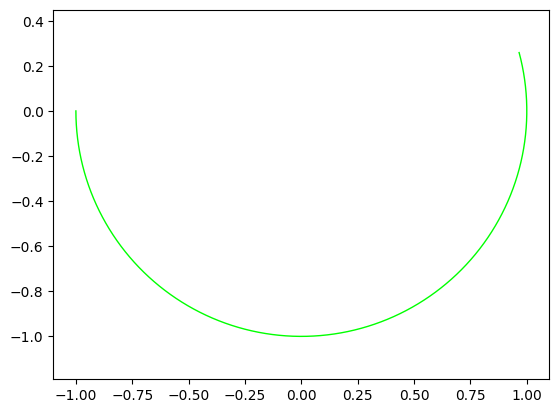

In [16]:
def arc_inverse(
    r=1,
    angle1=45,
    angle2=135,
    rotation=0,
    color="#0f0",
    alpha=1,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="b",
    markeredgecolor="r",
    markeredgewidth=1,
    ax=None,
    use_degree=True,
    plot=True,
    direction="cw",
    return_arc=False,
    **kwargs,
):
    arc(
        r,
        angle1,
        angle2,
        rotation,
        color,
        alpha,
        center,
        points,
        linestyle,
        linewidth,
        label,
        marker,
        markersize,
        markerfacecolor,
        markeredgecolor,
        markeredgewidth,
        ax,
        use_degree,
        plot,
        direction,
        return_arc,
        **kwargs,
    )


arc_inverse(1,np.pi/12,np.pi,0,use_degree=False)

## arc_dot

In [17]:
def arc_dot(
    r=1,
    angle1=45,
    angle2=135,
    rotation=0,
    color="#0f0",
    alpha=1,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="b",
    markeredgecolor="r",
    markeredgewidth=1,
    ax=None,
    use_degree=True,
    **kwargs,
):
    return arc(
        r,
        angle1,
        angle2,
        rotation,
        color,
        alpha,
        center,
        points,
        linestyle,
        linewidth,
        label,
        marker,
        markersize,
        markerfacecolor,
        markeredgecolor,
        markeredgewidth,
        ax,
        use_degree,
        plot=False,
        direction="ccw",
        return_arc=False,
        **kwargs,
    )
arc_dot(points=10)

(array([ 0.70710678,  0.57357644,  0.42261826,  0.25881905,  0.08715574,
        -0.08715574, -0.25881905, -0.42261826, -0.57357644, -0.70710678]),
 array([0.70710678, 0.81915204, 0.90630779, 0.96592583, 0.9961947 ,
        0.9961947 , 0.96592583, 0.90630779, 0.81915204, 0.70710678]))

## arc_dot_inverse

In [18]:
def arc_dot_inverse(
    r=1,
    angle1=45,
    angle2=135,
    rotation=0,
    color="#0f0",
    alpha=1,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="b",
    markeredgecolor="r",
    markeredgewidth=1,
    ax=None,
    use_degree=True,
    **kwargs,
):
    return arc(
        r,
        angle1,
        angle2,
        rotation,
        color,
        alpha,
        center,
        points,
        linestyle,
        linewidth,
        label,
        marker,
        markersize,
        markerfacecolor,
        markeredgecolor,
        markeredgewidth,
        ax,
        use_degree,
        plot=False,
        direction="cw",
        return_arc=False,
        **kwargs,
    )


arc_dot_inverse(points=10)

(array([-0.70710678, -0.96592583, -0.96592583, -0.70710678, -0.25881905,
         0.25881905,  0.70710678,  0.96592583,  0.96592583,  0.70710678]),
 array([ 0.70710678,  0.25881905, -0.25881905, -0.70710678, -0.96592583,
        -0.96592583, -0.70710678, -0.25881905,  0.25881905,  0.70710678]))

## 扩展

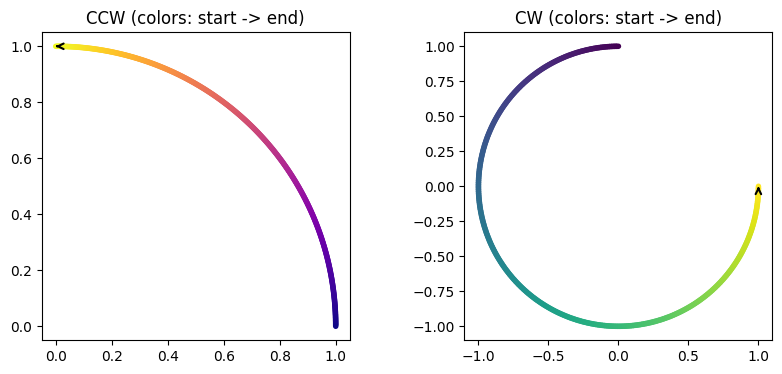

In [19]:
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib.pyplot as plt

def plot_arc_gradient(x, y, ax=None, cmap='viridis', linewidth=4, alpha=1.0, draw_arrow=True, arrow_kw=None, return_collection=False):
    """
    用渐变色绘制由 (x,y) 给定的弧；颜色沿着点顺序从 start -> end 变化。
    - x, y: 1D arrays
    - cmap: matplotlib colormap name
    - draw_arrow: 是否在弧末端画一个小箭头表示方向
    - arrow_kw: dict 传给 ax.annotate 的 arrowprops（颜色、宽度等）
    返回 LineCollection（如果 return_collection=True）
    """
    if ax is None:
        ax = plt.gca()
    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    # segments: (N-1, 2, 2)
    segments = np.concatenate([pts[:-1], pts[1:]], axis=1)
    # 归一化参数 t 沿弧长度（更均匀地分配颜色）
    seg_lengths = np.sqrt(((segments[:,1] - segments[:,0])**2).sum(axis=1))
    cumlen = np.concatenate([[0.0], np.cumsum(seg_lengths)])
    if cumlen[-1] == 0:
        norm_t = np.linspace(0, 1, len(segments))
    else:
        norm_t = (cumlen[:-1] + seg_lengths/2) / cumlen[-1]  # 每段中心点的归一化位置

    lc = LineCollection(segments, array=norm_t, cmap=plt.get_cmap(cmap), linewidths=linewidth, alpha=alpha, capstyle='round')
    ax.add_collection(lc)
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()

    if draw_arrow and len(x) >= 2:
        if arrow_kw is None:
            arrow_kw = dict(arrowstyle='->', color='k', linewidth=1.5, shrinkA=0, shrinkB=0)
        x0, y0 = x[-2], y[-2]
        x1, y1 = x[-1], y[-1]
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=arrow_kw)

    if return_collection:
        return lc

def demo_gradient_on_arc():
    # 示例：使用之前定义的 arc_point 函数（返回 x,y，当 plot=False）
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # CCW 示例
    x_ccw, y_ccw = arc_point(center=(0,0), point1=(1,0), point2=(0,1), plot=False, points=300, direction='ccw')
    plot_arc_gradient(x_ccw, y_ccw, ax=axes[0], cmap='plasma', linewidth=4, draw_arrow=True)
    axes[0].set_title('CCW (colors: start -> end)')

    # CW 示例
    x_cw, y_cw = arc_point(center=(0,0), point1=(1,0), point2=(0,1), plot=False, points=300, direction='cw')
    plot_arc_gradient(x_cw, y_cw, ax=axes[1], cmap='viridis', linewidth=4, draw_arrow=True)
    axes[1].set_title('CW (colors: start -> end)')

    plt.show()

# 运行 demo（如果 arc_point 已定义）
try:
    demo_gradient_on_arc()
except NameError as e:
    print('请先确保 notebook 中定义了 arc_point 函数（并能在 plot=False 下返回 x,y）。')

已保存示例图到: c:\\CPR\\cprdspy\\cprdspy\\CPR_matplotlib\\Arcs\\arc_demo.png


C:\Users\lbylzk\AppData\Local\Temp\ipykernel_28328\908316102.py:14: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=150, bbox_inches='tight')
C:\Users\lbylzk\AppData\Local\Temp\ipykernel_28328\908316102.py:14: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=150, bbox_inches='tight')
C:\Users\lbylzk\AppData\Local\Temp\ipykernel_28328\908316102.py:14: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=150, bbox_inches='tight')
C:\Users\lbylzk\AppData\Local\Temp\ipykernel_28328\908316102.py:14: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=150, bbox_inches='tight')
C:\Users\lbylzk\AppData\Local\Temp\ipykernel_28328\908316102.py:14: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) DejaVu S

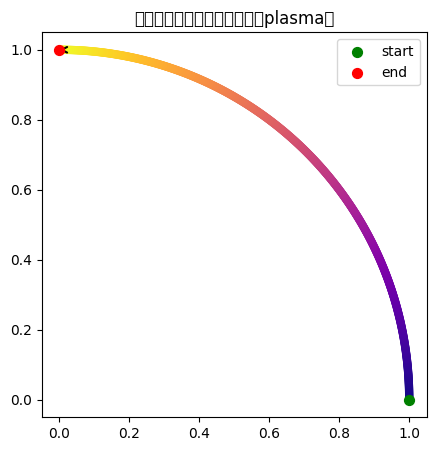

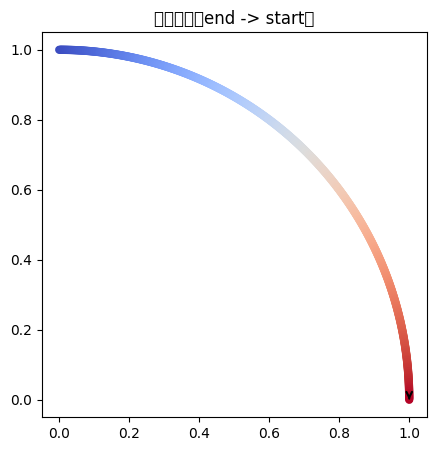

NameError: name 'arc_degree' is not defined

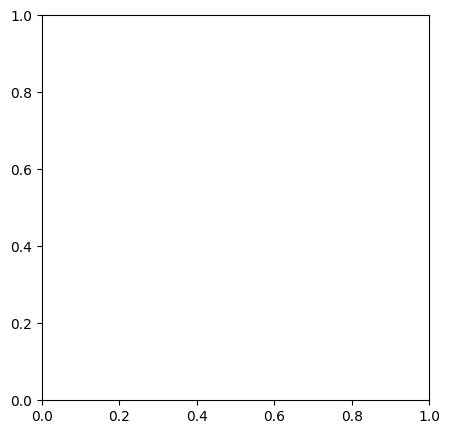

In [20]:
# 附加示例：在图上标出起点/终点、保存为文件，并展示如何反转渐变方向
fig, ax = plt.subplots(1, 1, figsize=(5,5))
# 取得一条示例弧（CCW）
x, y = arc_point(center=(0,0), point1=(1,0), point2=(0,1), plot=False, points=500, direction='ccw')
# 绘制渐变并返回集合
lc = plot_arc_gradient(x, y, ax=ax, cmap='plasma', linewidth=6, draw_arrow=True, return_collection=True)
# 标出起点(绿色)和终点(红色)
ax.scatter([x[0]], [y[0]], c='green', s=50, zorder=10, label='start')
ax.scatter([x[-1]], [y[-1]], c='red', s=50, zorder=10, label='end')
ax.legend()
ax.set_title('示例：带起终点标记与渐变（plasma）')
# 保存到仓库内的文件（可改路径）
out_path = r'c:\\CPR\\cprdspy\\cprdspy\\CPR_matplotlib\\Arcs\\arc_demo.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'已保存示例图到: {out_path}')
plt.show()

# 演示如何反转渐变（颜色从 end -> start）：
fig2, ax2 = plt.subplots(1,1,figsize=(5,5))
plot_arc_gradient(x[::-1], y[::-1], ax=ax2, cmap='coolwarm', linewidth=6, draw_arrow=True)
ax2.set_title('反转渐变（end -> start）')
plt.show()

# 如果想对 arc_degree 的输出使用渐变：示例（不绘制 arc_degree 自带的线）
fig3, ax3 = plt.subplots(1,1,figsize=(5,5))
x3, y3 = arc_degree(r=1, angle1=30, angle2=150, rotation=20, plot=False, points=600)
plot_arc_gradient(x3, y3, ax=ax3, cmap='inferno', linewidth=6, draw_arrow=True)
ax3.set_title('对 arc_degree 输出使用渐变')
plt.show()